# ♻️ **Solid Waste Management and Forecasting**  

<p style="font-family: Calibri, serif; text-align: left;
          font-size: 34px; letter-spacing: .85px; color: #e74c3c;">A data-driven approach to analyzing and predicting waste generation trends</p>

## 📚 **Table of Contents**
1. [Introduction](#introduction)
2. [Objectives](#objectives)
3. [Data Overview](#data-overview)
4. [Modeling & Forecasting](#modeling--forecasting)
5. [Results & Insights](#results--insights)



<p style="font-family: Calibri, serif; text-align: left;
          font-size: 28px; letter-spacing: .85px; color: #ffffff;">What is Forecasting</p>
          
<p style="font-family: Calibri, serif; text-align: left;
          font-size: 24px; letter-spacing: .85px; color: #ffffff;"><code></code>Forecasting predicts future values based on historical data, widely used in fields like waste management to anticipate trends. It involves analyzing patterns in time-series data (e.g., waste volume) using statistical or machine learning models. Common methods include ARIMA, exponential smoothing, and neural networks. Accurate forecasting aids resource allocation, operational planning, and policy-making. Challenges include handling seasonality, trends, and outliers. Improving accuracy involves data preprocessing, selecting appropriate models, and incorporating external factors (e.g., population growth). Regular model evaluation and updating ensure robust predictions, enabling efficient management of resources in dynamic environments like solid waste systems.</p>



<p style="font-family: Calibri, serif; text-align: left;
          font-size: 28px; letter-spacing: .85px; color: #ffffff;">🎯 Objective of Project</p>
          
<p style="font-family: Calibri, serif; text-align: left;
          font-size: 24px; letter-spacing: .85px; color: #ffffff;"><code></code>The objective of this project is to develop an accurate forecasting model for solid waste management using historical data on waste type, net weight, area, and ticket date. By analyzing this dataset, the project aims to predict future waste generation, enabling efficient resource allocation, optimized collection schedules, and informed policy decisions. The model will explore various forecasting techniques (e.g., ARIMA, Prophet, LSTM) to identify patterns and trends. Additionally, the project seeks to improve prediction accuracy by addressing data irregularities, incorporating external factors like population or seasonal trends, and validating models to support sustainable waste management practices.</p>




### 🗃️ <a name="data-overview"></a>**Data Overview**


| Feature     | Description                                |
|-------------|--------------------------------------------|
| `area`      | Area of waste collection  |
| `ticket_date`    |   Date              |
| `Waste_Type`| Type of waste (Sorted Organic Waste,Bulky Waste)    |
| `net_weight_kg`   | Total waste in KG                |

In [ ]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from uuid import uuid4

In [ ]:
#read data
df = pd.read_csv('dataset\moratuwa_2014-2018.csv')

NameError: name 'pd' is not defined

In [ ]:
# Preprocessing
df['ticket_date'] = pd.to_datetime(df['ticket_date'])
df = df.sort_values('ticket_date')

In [ ]:
# information about data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6691 entries, 0 to 6690
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   area           6691 non-null   object        
 1   ticket_date    6691 non-null   datetime64[ns]
 2   waste_type     6691 non-null   object        
 3   net_weight_kg  6691 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 261.4+ KB


In [ ]:
#display the top 5 rows of data
df.head()

,area,ticket_date,waste_type,net_weight_kg
0,Moratuwa MC,2014-01-12,Sorted Organic Waste,47230
1,Moratuwa MC,2014-02-12,Sorted Organic Waste,54670
2,Moratuwa MC,2014-03-12,Sorted Organic Waste,43670
3,Moratuwa MC,2014-04-12,Sorted Organic Waste,40410
4,Moratuwa MC,2014-05-12,Sorted Organic Waste,34590


In [ ]:
#display the bottom 5 rows of data
df.tail()

,area,ticket_date,waste_type,net_weight_kg
6687,Moratuwa MC,2018-12-11,MSW,10370
6689,Moratuwa MC,2018-12-11,Soil With Waste,9290
6685,Moratuwa MC,2018-12-11,Bulky Waste,7190
6686,Moratuwa MC,2018-12-11,Industrial Waste,6210
6690,Moratuwa MC,2018-12-11,Sorted Organic Waste,83910


In [ ]:
#value counts on waste_type
df['waste_type'].value_counts()

waste_type
MSW                       1307
Sorted Organic Waste      1208
Slaghter House Waste      1105
Bulky Waste               1022
Industrial Waste           842
Soil With Waste            777
Sanitary Waste             236
C&D Waste                  102
Indutrial Sludge Waste      41
Soil                        16
Saw Dust                    14
Polythyne & Regiform        11
Mesuring                     5
Wood Debris                  3
Special Waste                1
Wood Trank                   1
Name: count, dtype: int64

In [ ]:
df['area'].value_counts()

area
Moratuwa MC    6691
Name: count, dtype: int64

In [ ]:
# define waste types
waste_types = ['MSW', 'Sorted Organic Waste', 'Slaghter House Waste', 'Bulky Waste', 
               'Industrial Waste', 'Soil With Waste', 'Sanitary Waste', 'C&D Waste', 
               'Indutrial Sludge Waste', 'Soil', 'Saw Dust', 'Polythyne & Regiform', 
               'Mesuring', 'Wood Debris', 'Special Waste', 'Wood Trank']

In [ ]:
# Aggregate by date, keeping waste_type
daily_data = df.groupby(['ticket_date', 'waste_type'])['net_weight_kg'].sum().unstack(fill_value=0).reset_index()
daily_data = daily_data.set_index('ticket_date')

# Filter for 2018 data
daily_data_2018 = daily_data[daily_data.index.year == 2018]

# Add time-based features
daily_data_2018['day_of_week'] = daily_data_2018.index.dayofweek
daily_data_2018['month'] = daily_data_2018.index.month
daily_data_2018['day_of_year'] = daily_data_2018.index.dayofyear

# Total net_weight_kg for univariate forecasting
daily_data_2018['total_weight'] = daily_data_2018[waste_types].sum(axis=1)

# Add Gaussian noise to total_weight
np.random.seed(42)  # For reproducibility
noise = np.random.normal(loc=0, scale=0.1 * daily_data_2018['total_weight'].std(), size=len(daily_data_2018))
daily_data_2018['total_weight'] = daily_data_2018['total_weight'] + noise
daily_data_2018['total_weight'] = daily_data_2018['total_weight'].clip(lower=0)  # Ensure no negative weights

C:\Users\0860\AppData\Local\Temp\ipykernel_12580\1672480529.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_data_2018['day_of_week'] = daily_data_2018.index.dayofweek
C:\Users\0860\AppData\Local\Temp\ipykernel_12580\1672480529.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_data_2018['month'] = daily_data_2018.index.month
C:\Users\0860\AppData\Local\Temp\ipykernel_12580\1672480529.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

In [ ]:
# Outlier treatment using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# Cap outliers
lower_iqr, upper_iqr = detect_outliers_iqr(daily_data_2018, 'total_weight')
daily_data_2018['total_weight'] = daily_data_2018['total_weight'].clip(lower=lower_iqr, upper=upper_iqr)


C:\Users\0860\AppData\Local\Temp\ipykernel_12580\3949075054.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_data_2018['total_weight'] = daily_data_2018['total_weight'].clip(lower=lower_iqr, upper=upper_iqr)


<p style="font-family: Calibri, serif; text-align: left;
          font-size: 28px; letter-spacing: .85px; color: #ffffff;">Linear Regression</p>


Training Linear Regression with learning rate 0.001...
Linear Regression (lr=0.001) - MAE: 4969.42 kg, RMSE: 5752.06 kg, MAPE: 5.55%, R²: 0.6013

Training Linear Regression with learning rate 0.01...
Linear Regression (lr=0.01) - MAE: 4313.96 kg, RMSE: 5453.44 kg, MAPE: 4.87%, R²: 0.6416

Training Linear Regression with learning rate 0.005...
Linear Regression (lr=0.005) - MAE: 4474.47 kg, RMSE: 5385.89 kg, MAPE: 5.02%, R²: 0.6505


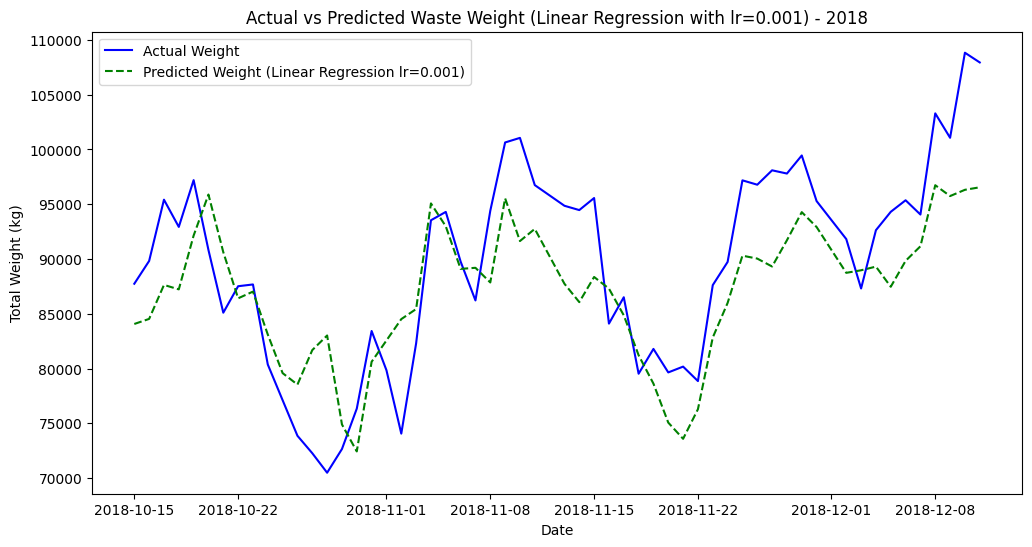

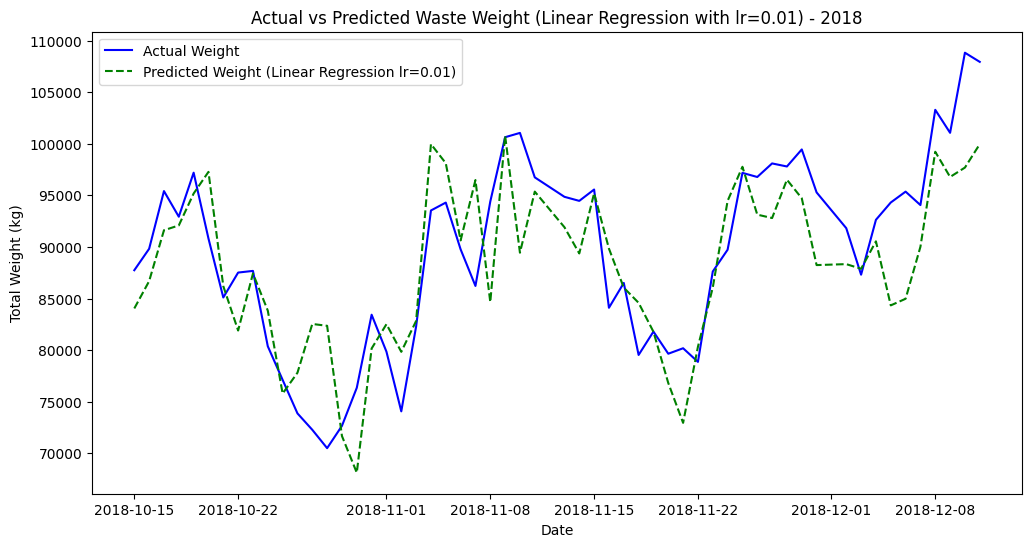

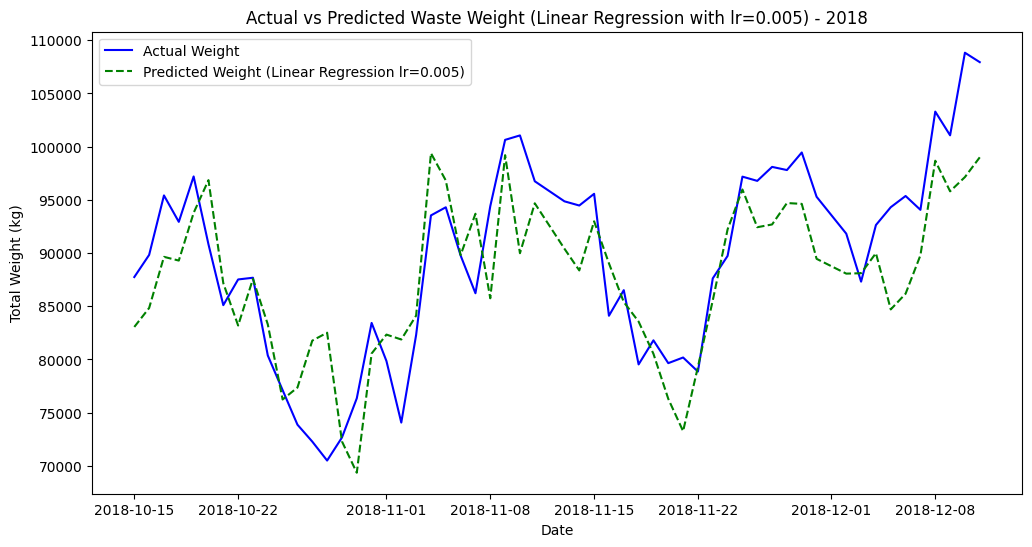

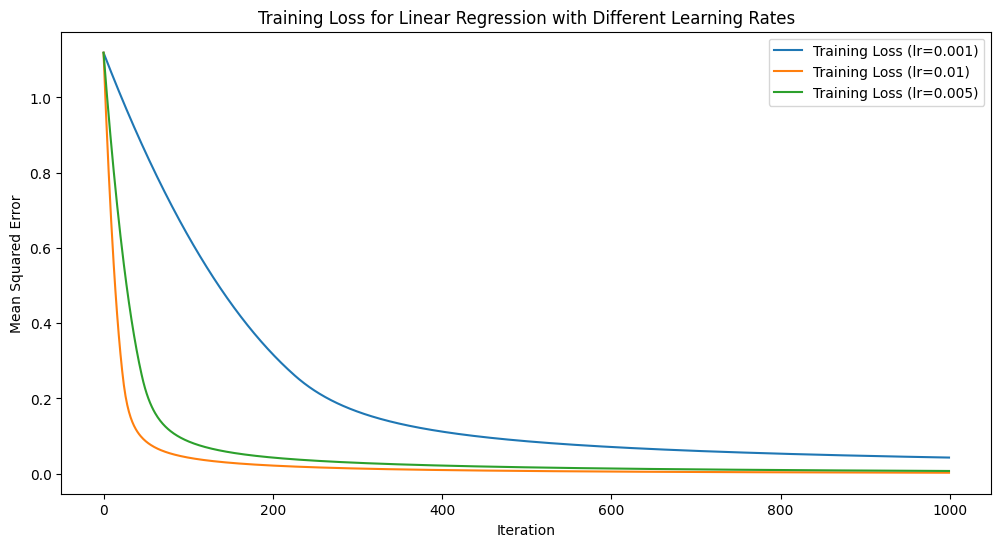

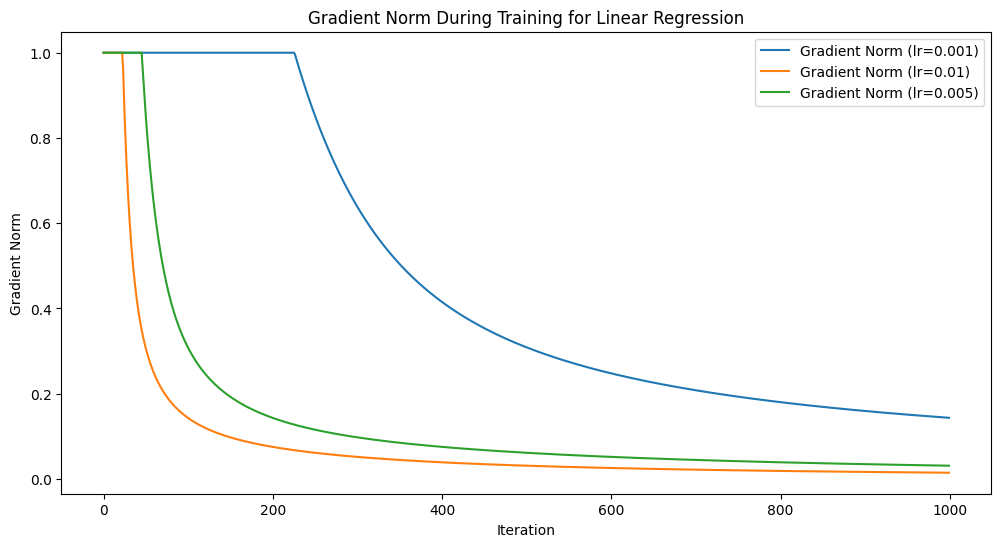

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Read data
df = pd.read_csv('dataset\moratuwa_2014-2018.csv')

# Preprocessing
df['ticket_date'] = pd.to_datetime(df['ticket_date'])
df = df.sort_values('ticket_date')

# Define waste types
waste_types = ['MSW', 'Sorted Organic Waste', 'Slaghter House Waste', 'Bulky Waste', 
               'Industrial Waste', 'Soil With Waste', 'Sanitary Waste', 'C&D Waste', 
               'Indutrial Sludge Waste', 'Soil', 'Saw Dust', 'Polythyne & Regiform', 
               'Mesuring', 'Wood Debris', 'Special Waste', 'Wood Trank']

# Aggregate by date, keeping waste_type
daily_data = df.groupby(['ticket_date', 'waste_type'])['net_weight_kg'].sum().unstack(fill_value=0).reset_index()
daily_data = daily_data.set_index('ticket_date')

# Add time-based features
daily_data['day_of_week'] = daily_data.index.dayofweek
daily_data['month'] = daily_data.index.month
daily_data['day_of_year'] = daily_data.index.dayofyear

# Total net_weight_kg
daily_data['total_weight'] = daily_data[waste_types].sum(axis=1)

# Outlier treatment using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# Cap outliers
lower_iqr, upper_iqr = detect_outliers_iqr(daily_data, 'total_weight')
daily_data_cleaned = daily_data.copy()
daily_data_cleaned['total_weight'] = daily_data_cleaned['total_weight'].clip(lower=lower_iqr, upper=upper_iqr)

# Function to process data for a specific year
def process_year_data(year):
    # Filter data for the specified year
    daily_data_year = daily_data_cleaned[daily_data_cleaned.index.year == year].copy()
    
    # Enhance data with subtle variability (1% noise)
    np.random.seed(42)  # For reproducibility
    daily_data_year['total_weight_enhanced'] = daily_data_year['total_weight'] * (1 + np.random.normal(0, 0.01, daily_data_year.shape[0]))
    
    # Add lagged feature and moving average
    daily_data_year['lag_1'] = daily_data_year['total_weight_enhanced'].shift(1)
    daily_data_year['ma_7'] = daily_data_year['total_weight_enhanced'].rolling(window=7).mean()
    daily_data_year = daily_data_year.dropna()

    # Prepare features
    features = waste_types + ['day_of_week', 'month', 'day_of_year', 'total_weight_enhanced', 'lag_1', 'ma_7']
    data_year = daily_data_year[features].values
    scaler = StandardScaler()
    data_scaled_year = scaler.fit_transform(data_year)

    # Create sequences
    def create_sequences(data, seq_length):
        X, y = [], []
        for i in range(len(data) - seq_length):
            X.append(data[i:i + seq_length, :-1])  # All features except total_weight_enhanced
            y.append(data[i + seq_length, -1])  # Predict total_weight_enhanced
        return np.array(X), np.array(y)

    seq_length = 30
    X_year, y_year = create_sequences(data_scaled_year, seq_length)

    # Train-test split
    train_size = int(0.8 * len(X_year))
    X_train_year, X_test_year = X_year[:train_size], X_year[train_size:]
    y_train_year, y_test_year = y_year[:train_size], y_year[train_size:]
    test_dates_year = daily_data_year.index[seq_length + train_size:seq_length + len(X_year)]

    return X_train_year, X_test_year, y_train_year, y_test_year, test_dates_year, scaler, data_scaled_year.shape[1]

# Set the year to analyze
year_to_analyze = 2018

# Process data for the selected year
X_train_year, X_test_year, y_train_year, y_test_year, test_dates_year, scaler, n_features = process_year_data(year_to_analyze)

# Flatten sequence data for Linear Regression
X_train_flat = X_train_year.reshape(X_train_year.shape[0], -1)  # (samples, seq_length * (n_features-1))
X_test_flat = X_test_year.reshape(X_test_year.shape[0], -1)

# Custom Linear Regression with Gradient Descent and Gradient Clipping
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000, clip_value=1.0):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.clip_value = clip_value  # Gradient clipping threshold
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.gradient_norms = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            # Forward pass
            y_pred = np.dot(X, self.weights) + self.bias

            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Gradient clipping
            gradient_norm = np.sqrt(np.sum(dw ** 2) + db ** 2)
            if gradient_norm > self.clip_value:
                dw = dw * self.clip_value / gradient_norm
                db = db * self.clip_value / gradient_norm

            # Store clipped gradient norm
            self.gradient_norms.append(min(gradient_norm, self.clip_value))

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Compute MSE loss
            loss = np.mean((y_pred - y) ** 2)
            if np.isnan(loss):
                print(f"Warning: NaN loss detected at iteration {_}. Stopping training.")
                break
            self.loss_history.append(loss)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Define learning rates to test (simulating optimizer variation)
learning_rates = [0.001, 0.01, 0.005]  # Replaced 0.1 with 0.005 for stability

# Function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    y_true = np.where(y_true == 0, 1e-10, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Train and evaluate Linear Regression with different learning rates
results = {}
for lr in learning_rates:
    print(f"\nTraining Linear Regression with learning rate {lr}...")
    model = LinearRegressionGD(learning_rate=lr, n_iterations=1000, clip_value=1.0)
    model.fit(X_train_flat, y_train_year)
    
    # Predict
    y_pred = model.predict(X_test_flat)
    
    # Inverse transform
    dummy_pred = np.zeros((len(y_pred), n_features))
    dummy_pred[:, -1] = y_pred
    y_pred_inv = scaler.inverse_transform(dummy_pred)[:, -1]
    
    dummy_test = np.zeros((len(y_test_year), n_features))
    dummy_test[:, -1] = y_test_year
    y_test_inv = scaler.inverse_transform(dummy_test)[:, -1]
    
    # Evaluate (skip if NaN detected)
    if np.any(np.isnan(y_pred_inv)):
        print(f"Warning: NaN predictions detected for lr={lr}. Skipping evaluation.")
        continue
    
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)
    r2 = r2_score(y_test_inv, y_pred_inv)
    print(f"Linear Regression (lr={lr}) - MAE: {mae:.2f} kg, RMSE: {rmse:.2f} kg, MAPE: {mape:.2f}%, R²: {r2:.4f}")
    
    results[str(lr)] = {
        'model': model,
        'y_pred_inv': y_pred_inv,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'r2': r2
    }

# Visualizations
# 1. Actual vs Predicted for each learning rate
for lr in learning_rates:
    if str(lr) not in results:
        continue
    plt.figure(figsize=(12, 6))
    plt.plot(test_dates_year, y_test_inv, label='Actual Weight', color='blue')
    plt.plot(test_dates_year, results[str(lr)]['y_pred_inv'], 
             label=f'Predicted Weight (Linear Regression lr={lr})', color='green', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Total Weight (kg)')
    plt.title(f'Actual vs Predicted Waste Weight (Linear Regression with lr={lr}) - {year_to_analyze}')
    plt.legend()
    plt.savefig(f'linear_regression_forecast_2018_lr_{str(lr).replace(".", "_")}.png')

# 2. Training Loss Comparison
plt.figure(figsize=(12, 6))
for lr in learning_rates:
    if str(lr) not in results:
        continue
    plt.plot(results[str(lr)]['model'].loss_history, label=f'Training Loss (lr={lr})')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('Training Loss for Linear Regression with Different Learning Rates')
plt.legend()
plt.savefig('linear_regression_loss_comparison_2018.png')

# 3. Gradient Norm Comparison
plt.figure(figsize=(12, 6))
for lr in learning_rates:
    if str(lr) not in results:
        continue
    plt.plot(results[str(lr)]['model'].gradient_norms, label=f'Gradient Norm (lr={lr})')
plt.xlabel('Iteration')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norm During Training for Linear Regression')
plt.legend()
plt.savefig('gradient_norm_comparison_2018.png')

<p style="font-family: Calibri, serif; text-align: left;
          font-size: 28px; letter-spacing: .85px; color: #ffffff;">LSTM Model with diffrent Optimizers</p>


Training LSTM with Adam optimizer...

Epoch 1/20

7/7 [==============================] - 3s 115ms/step - loss: 0.9121 - val_loss: 0.7456
Epoch 2/20
7/7 [==============================] - 0s 14ms/step - loss: 0.6087 - val_loss: 0.6582
Epoch 3/20
7/7 [==============================] - 0s 14ms/step - loss: 0.4229 - val_loss: 0.5263
Epoch 4/20
7/7 [==============================] - 0s 19ms/step - loss: 0.3285 - val_loss: 0.4215
Epoch 5/20
7/7 [==============================] - 0s 15ms/step - loss: 0.2940 - val_loss: 0.3539
Epoch 6/20
7/7 [==============================] - 0s 15ms/step - loss: 0.2506 - val_loss: 0.3063
Epoch 7/20
7/7 [==============================] - 0s 15ms/step - loss: 0.2019 - val_loss: 0.2726
Epoch 8/20
7/7 [==============================] - 0s 15ms/step - loss: 0.2012 - val_loss: 0.2429
Epoch 9/20
7/7 [==============================] - 0s 17ms/step - loss: 0.1864 - val_loss: 0.2163
Epoch 10/20
7/7 [==============================] - 0s 14ms/step - loss: 0.1451 - val_l

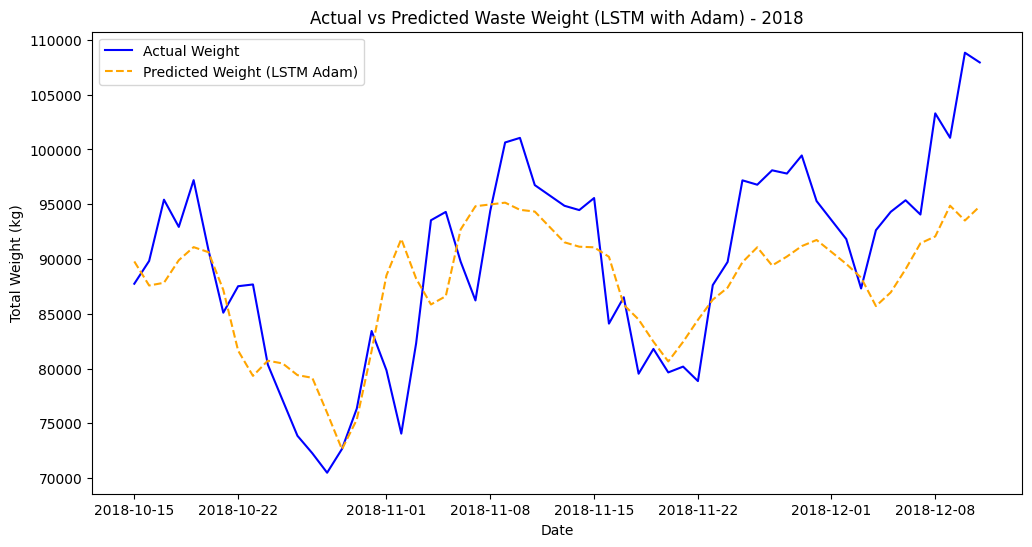

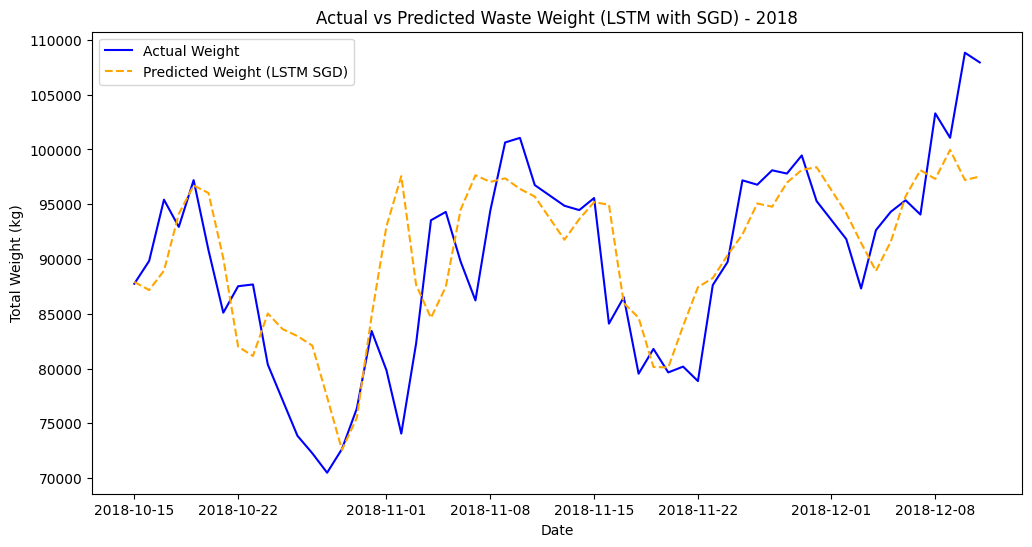

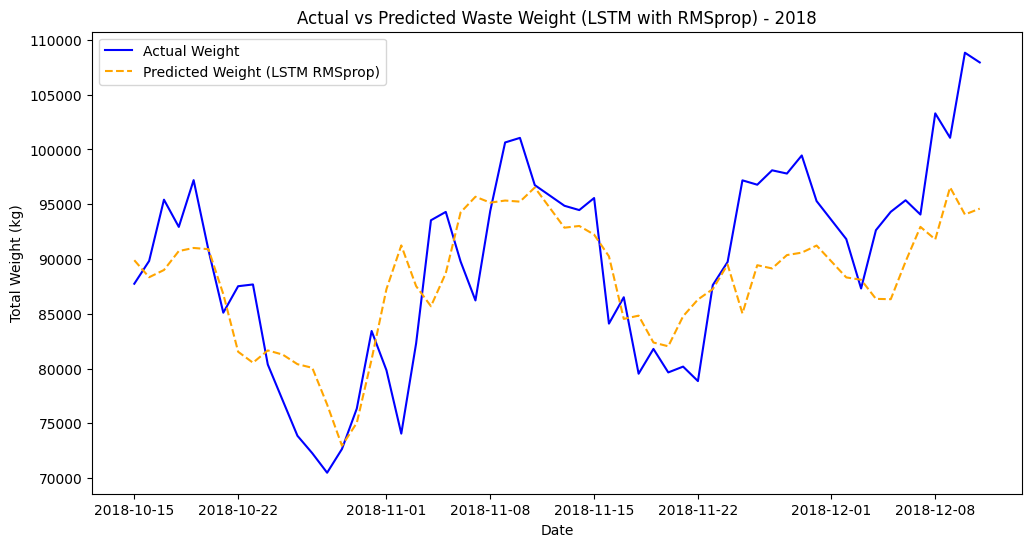

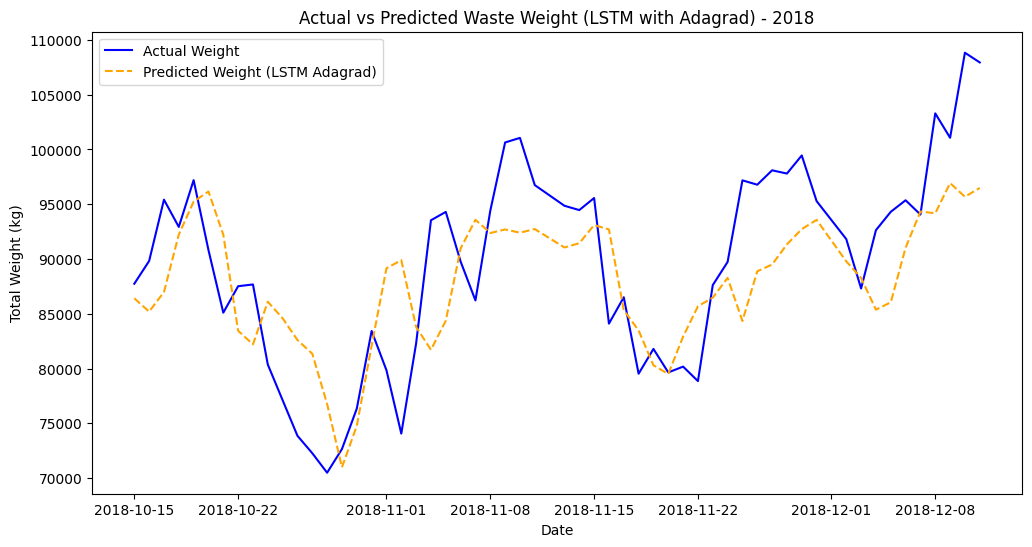

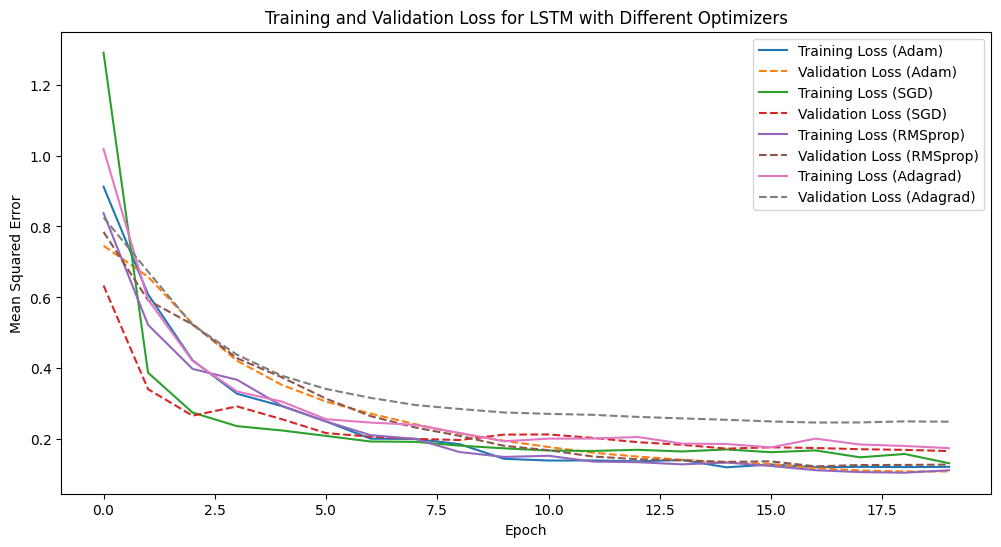

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adagrad

# Read data
df = pd.read_csv('dataset\moratuwa_2014-2018.csv')

# Preprocessing
df['ticket_date'] = pd.to_datetime(df['ticket_date'])
df = df.sort_values('ticket_date')

# Define waste types
waste_types = ['MSW', 'Sorted Organic Waste', 'Slaghter House Waste', 'Bulky Waste', 
               'Industrial Waste', 'Soil With Waste', 'Sanitary Waste', 'C&D Waste', 
               'Indutrial Sludge Waste', 'Soil', 'Saw Dust', 'Polythyne & Regiform', 
               'Mesuring', 'Wood Debris', 'Special Waste', 'Wood Trank']

# Aggregate by date, keeping waste_type
daily_data = df.groupby(['ticket_date', 'waste_type'])['net_weight_kg'].sum().unstack(fill_value=0).reset_index()
daily_data = daily_data.set_index('ticket_date')

# Add time-based features
daily_data['day_of_week'] = daily_data.index.dayofweek
daily_data['month'] = daily_data.index.month
daily_data['day_of_year'] = daily_data.index.dayofyear

# Total net_weight_kg
daily_data['total_weight'] = daily_data[waste_types].sum(axis=1)

# Outlier treatment using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# Cap outliers
lower_iqr, upper_iqr = detect_outliers_iqr(daily_data, 'total_weight')
daily_data_cleaned = daily_data.copy()
daily_data_cleaned['total_weight'] = daily_data_cleaned['total_weight'].clip(lower=lower_iqr, upper=upper_iqr)

# Function to process data for a specific year
def process_year_data(year):
    # Filter data for the specified year
    daily_data_year = daily_data_cleaned[daily_data_cleaned.index.year == year].copy()
    
    # Enhance data with subtle variability (1% noise)
    np.random.seed(42)  # For reproducibility
    daily_data_year['total_weight_enhanced'] = daily_data_year['total_weight'] * (1 + np.random.normal(0, 0.01, daily_data_year.shape[0]))
    
    # Add lagged feature and moving average
    daily_data_year['lag_1'] = daily_data_year['total_weight_enhanced'].shift(1)
    daily_data_year['ma_7'] = daily_data_year['total_weight_enhanced'].rolling(window=7).mean()
    daily_data_year = daily_data_year.dropna()

    # Prepare features
    features = waste_types + ['day_of_week', 'month', 'day_of_year', 'total_weight_enhanced', 'lag_1', 'ma_7']
    data_year = daily_data_year[features].values
    scaler = StandardScaler()
    data_scaled_year = scaler.fit_transform(data_year)

    # Create sequences
    def create_sequences(data, seq_length):
        X, y = [], []
        for i in range(len(data) - seq_length):
            X.append(data[i:i + seq_length, :-1])  # All features except total_weight_enhanced
            y.append(data[i + seq_length, -1])  # Predict total_weight_enhanced
        return np.array(X), np.array(y)

    seq_length = 30
    X_year, y_year = create_sequences(data_scaled_year, seq_length)

    # Train-test split
    train_size = int(0.8 * len(X_year))
    X_train_year, X_test_year = X_year[:train_size], X_year[train_size:]
    y_train_year, y_test_year = y_year[:train_size], y_year[train_size:]
    test_dates_year = daily_data_year.index[seq_length + train_size:seq_length + len(X_year)]

    return X_train_year, X_test_year, y_train_year, y_test_year, test_dates_year, scaler, data_scaled_year.shape[1]

# Set the year to analyze
year_to_analyze = 2018

# Process data for the selected year
X_train_year, X_test_year, y_train_year, y_test_year, test_dates_year, scaler, n_features = process_year_data(year_to_analyze)

# Define optimizer configurations
optimizers = {
    'Adam': {'class': Adam, 'kwargs': {'learning_rate': 0.001}},
    'SGD': {'class': SGD, 'kwargs': {'learning_rate': 0.01, 'momentum': 0.9}},
    'RMSprop': {'class': RMSprop, 'kwargs': {'learning_rate': 0.001}},
    'Adagrad': {'class': Adagrad, 'kwargs': {'learning_rate': 0.01}}
}

# Function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    y_true = np.where(y_true == 0, 1e-10, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Function to create LSTM model
def create_lstm_model(optimizer):
    model = Sequential([
        LSTM(50, activation='tanh', input_shape=(30, X_train_year.shape[2]), return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=optimizer, loss='mse')
    return model

# Train and evaluate LSTM models with different optimizers
results = {}
for opt_name, opt_config in optimizers.items():
    print(f"\nTraining LSTM with {opt_name} optimizer...")
    # Create fresh optimizer instance
    optimizer = opt_config['class'](**opt_config['kwargs'])
    model = create_lstm_model(optimizer)
    history = model.fit(X_train_year, y_train_year, epochs=20, batch_size=32, validation_split=0.1, verbose=1)
    
    # Predict
    y_pred = model.predict(X_test_year)
    
    # Inverse transform
    dummy_pred = np.zeros((len(y_pred), n_features))
    dummy_pred[:, -1] = y_pred.flatten()
    y_pred_inv = scaler.inverse_transform(dummy_pred)[:, -1]
    
    dummy_test = np.zeros((len(y_test_year), n_features))
    dummy_test[:, -1] = y_test_year
    y_test_inv = scaler.inverse_transform(dummy_test)[:, -1]
    
    # Evaluate
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)
    r2 = r2_score(y_test_inv, y_pred_inv)
    print(f"LSTM ({opt_name}) - MAE: {mae:.2f} kg, RMSE: {rmse:.2f} kg, MAPE: {mape:.2f}%, R²: {r2:.4f}")
    
    results[opt_name] = {
        'history': history.history,
        'y_pred_inv': y_pred_inv,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'r2': r2
    }

# Visualizations
# 1. Actual vs Predicted for each optimizer
for opt_name in optimizers.keys():
    plt.figure(figsize=(12, 6))
    plt.plot(test_dates_year, y_test_inv, label='Actual Weight', color='blue')
    plt.plot(test_dates_year, results[opt_name]['y_pred_inv'], 
             label=f'Predicted Weight (LSTM {opt_name})', color='orange', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Total Weight (kg)')
    plt.title(f'Actual vs Predicted Waste Weight (LSTM with {opt_name}) - {year_to_analyze}')
    plt.legend()
    plt.savefig(f'lstm_forecast_2018_{opt_name.lower()}.png')

# 2. Training and Validation Loss Comparison
plt.figure(figsize=(12, 6))
for opt_name in optimizers.keys():
    plt.plot(results[opt_name]['history']['loss'], 
             label=f'Training Loss ({opt_name})')
    plt.plot(results[opt_name]['history']['val_loss'], 
             label=f'Validation Loss ({opt_name})', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training and Validation Loss for LSTM with Different Optimizers')
plt.legend()
plt.savefig('lstm_loss_comparison_2018.png')

<p style="font-family: Calibri, serif; text-align: left;
          font-size: 28px; letter-spacing: .85px; color: #ffffff;">Recurrent Neural Network (RNN) Model</p>

<p style="font-family: Calibri, serif; text-align: left;
          font-size: 24px; letter-spacing: .85px; color: #e74c3c;">The RNN model is a type of neural network designed for sequential data, making it suitable for time series forecasting. It processes the sequence of features to predict the next value, with dropout for regularization to prevent overfitting.</p>

<p style="font-family: Calibri, serif; text-align: left;
          font-size: 28px; letter-spacing: .85px; color: #ffffff;">Gated Recurrent Unit (GRU) Model</p>

<p style="font-family: Calibri, serif; text-align: left;
          font-size: 24px; letter-spacing: .85px; color: #e74c3c;">GRU is an advanced RNN variant that uses gating mechanisms to better handle long-term dependencies and is computationally efficient. It’s well-suited for time series with complex patterns like waste weight data.</p>


Pre-training GRU on 2014-2017 data...
Epoch 1/20
29/29 [==============================] - 3s 29ms/step - loss: 0.5308 - val_loss: 0.1301
Epoch 2/20
29/29 [==============================] - 0s 12ms/step - loss: 0.1527 - val_loss: 0.0947
Epoch 3/20
29/29 [==============================] - 0s 11ms/step - loss: 0.1130 - val_loss: 0.0770
Epoch 4/20
29/29 [==============================] - 0s 11ms/step - loss: 0.1043 - val_loss: 0.0796
Epoch 5/20
29/29 [==============================] - 0s 12ms/step - loss: 0.0960 - val_loss: 0.0727
Epoch 6/20
29/29 [==============================] - 0s 12ms/step - loss: 0.0957 - val_loss: 0.0771
Epoch 7/20
29/29 [==============================] - 0s 10ms/step - loss: 0.0832 - val_loss: 0.0766
Epoch 8/20
29/29 [==============================] - 0s 11ms/step - loss: 0.0756 - val_loss: 0.0670
Epoch 9/20
29/29 [==============================] - 0s 11ms/step - loss: 0.0788 - val_loss: 0.0622
Epoch 10/20
29/29 [==============================] - 0s 13ms/step - lo

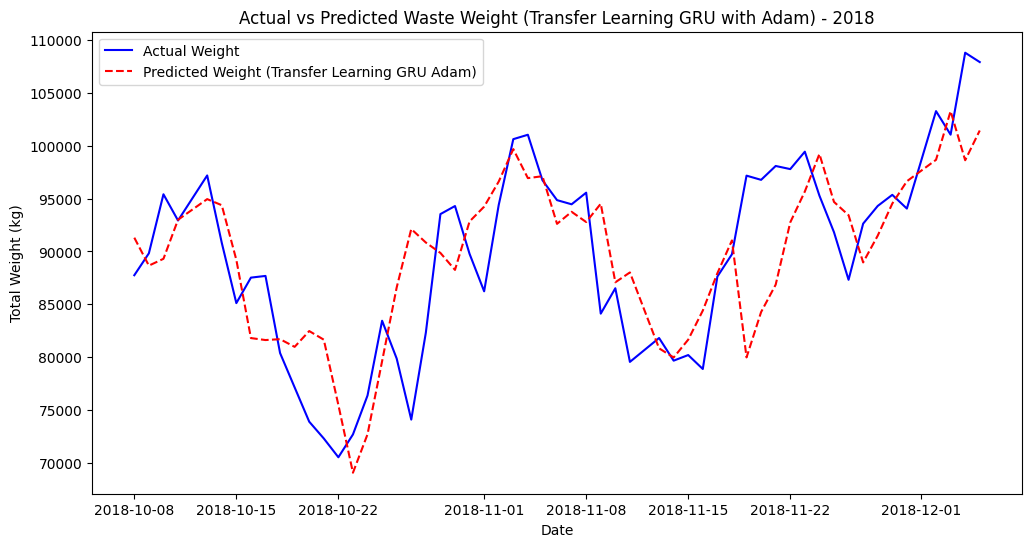

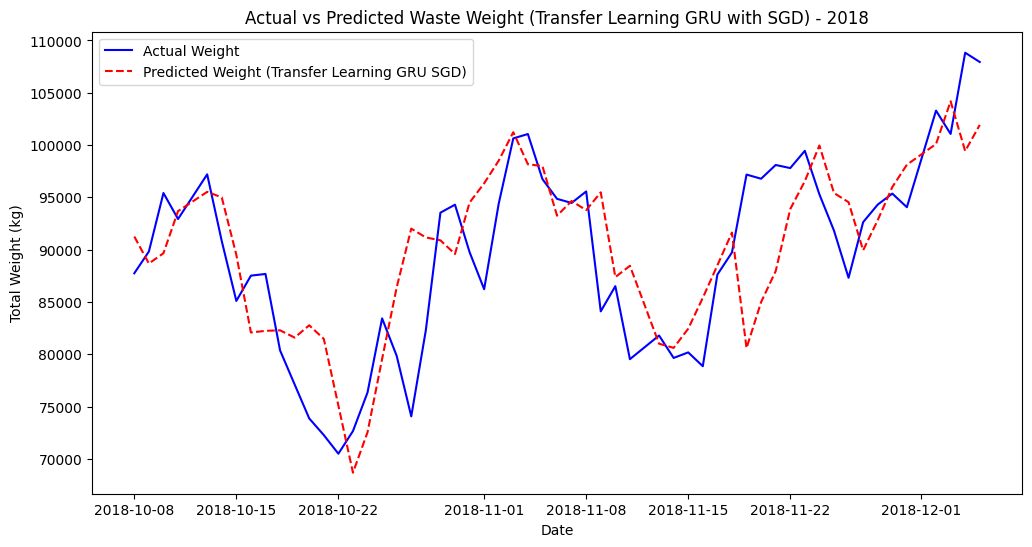

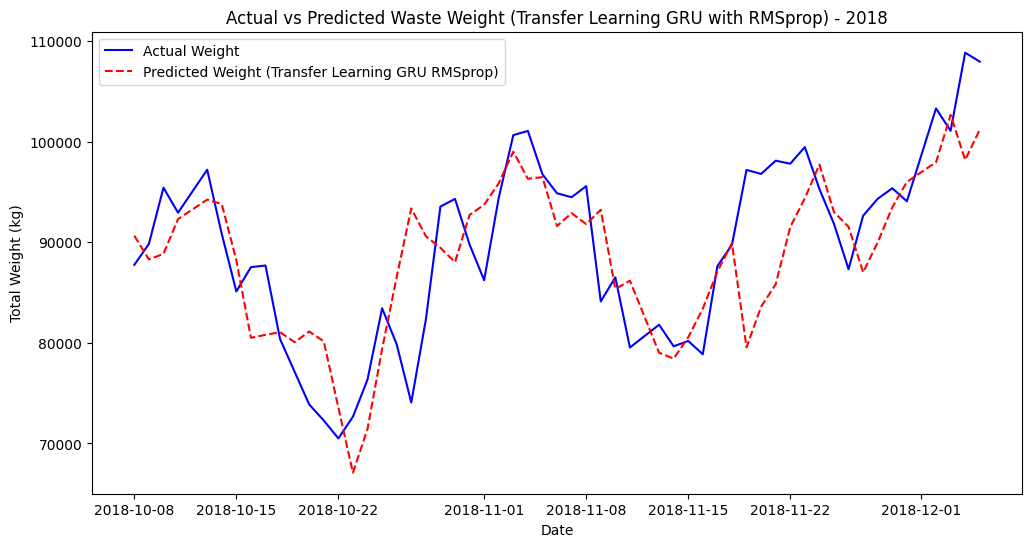

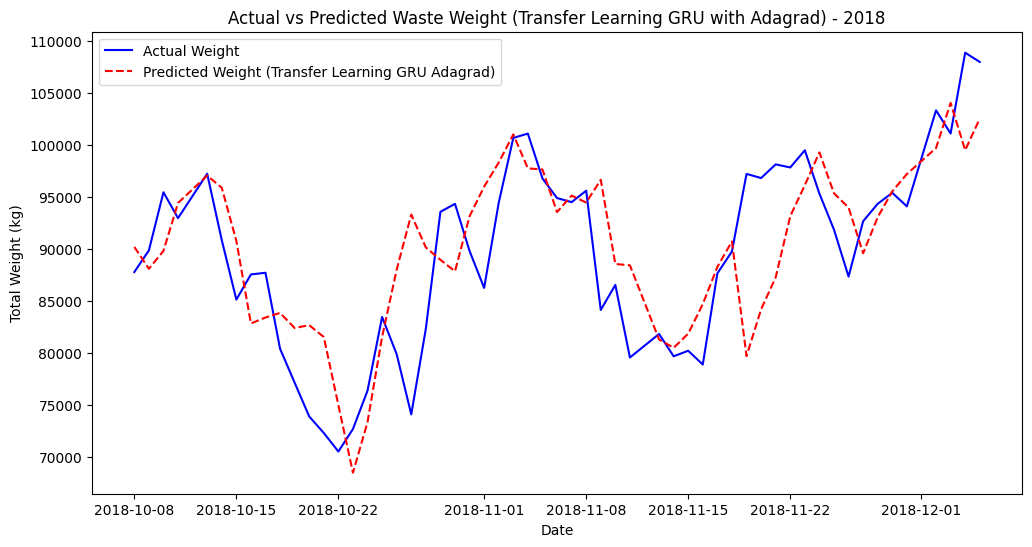

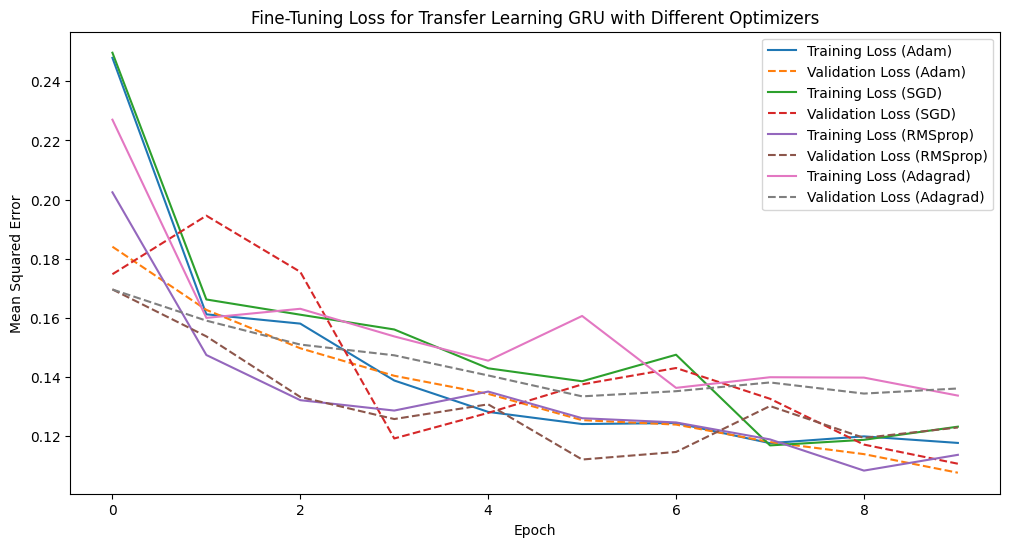

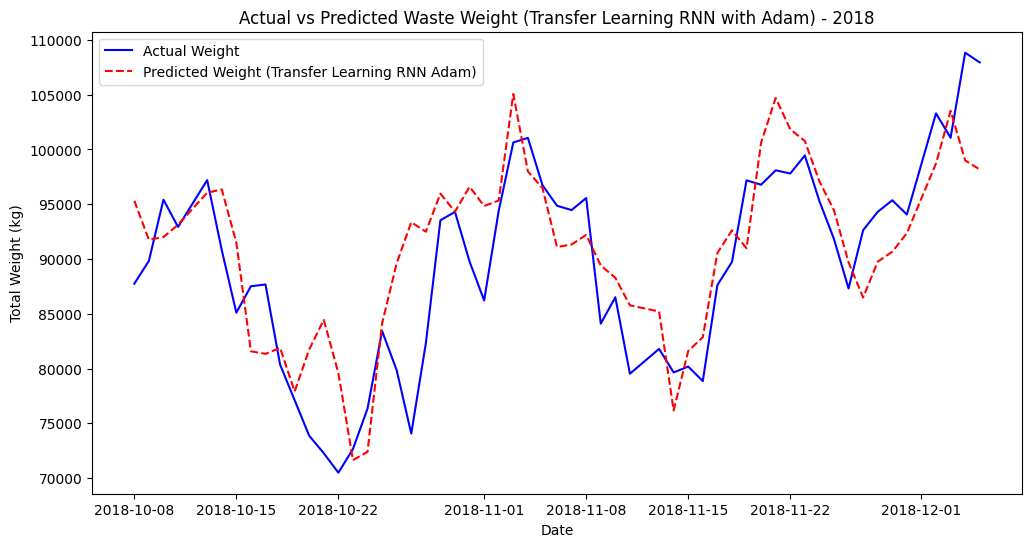

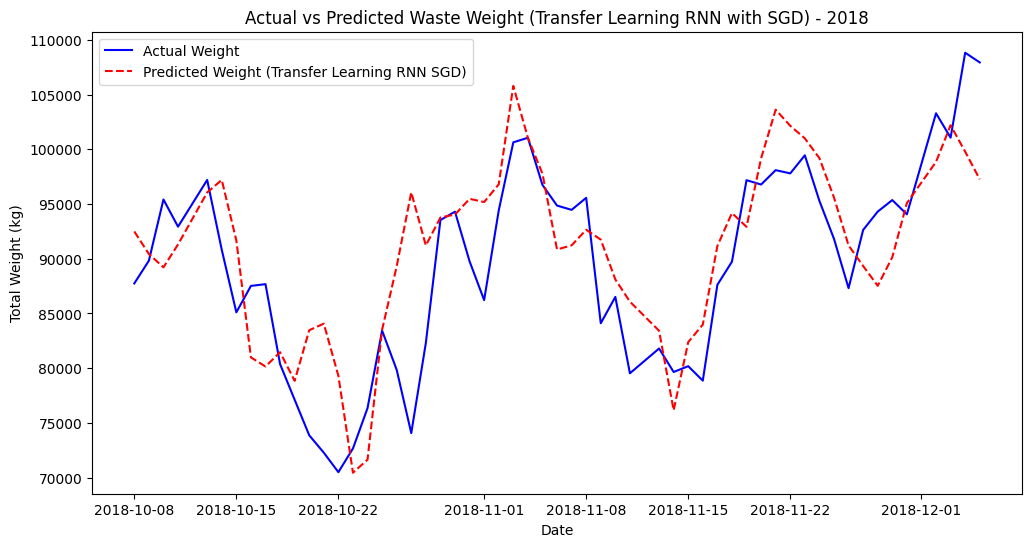

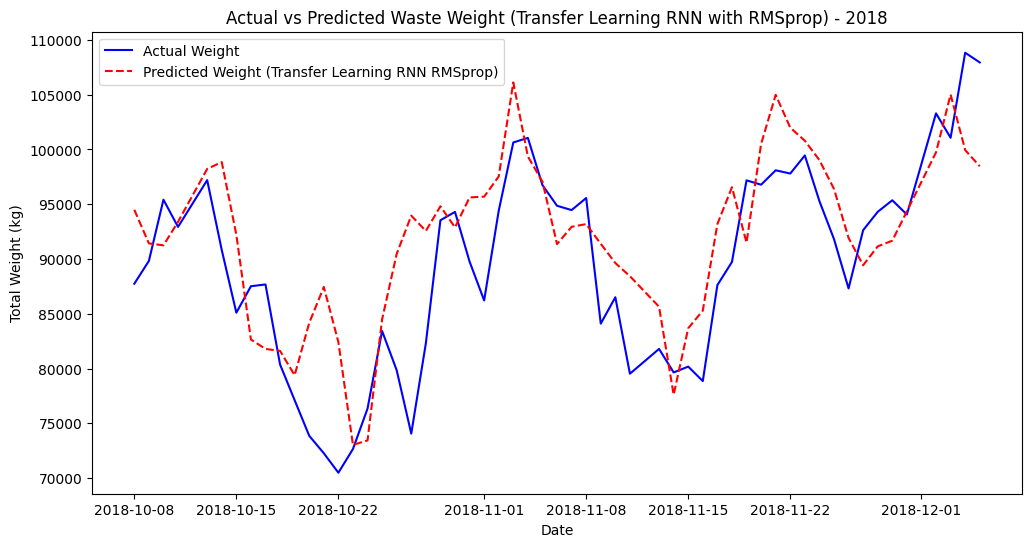

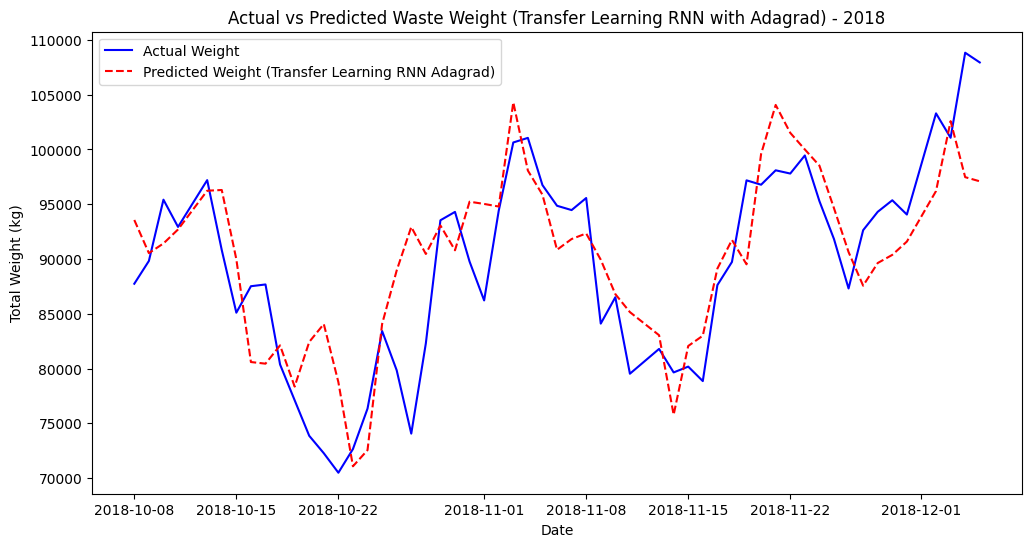

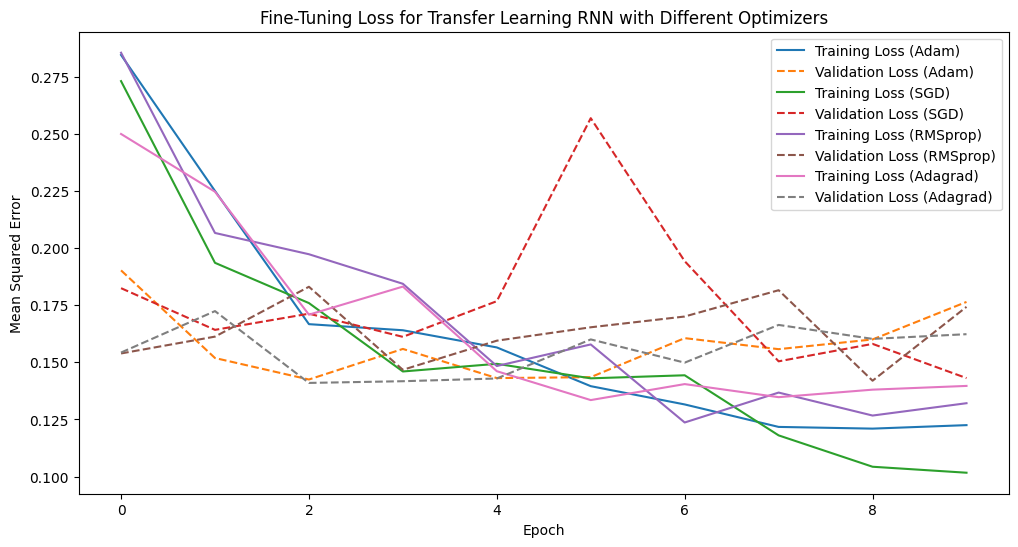

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adagrad

# Read data
df = pd.read_csv('dataset\moratuwa_2014-2018.csv')

# Preprocessing
df['ticket_date'] = pd.to_datetime(df['ticket_date'])
df = df.sort_values('ticket_date')

# Define waste types
waste_types = ['MSW', 'Sorted Organic Waste', 'Slaghter House Waste', 'Bulky Waste', 
               'Industrial Waste', 'Soil With Waste', 'Sanitary Waste', 'C&D Waste', 
               'Indutrial Sludge Waste', 'Soil', 'Saw Dust', 'Polythyne & Regiform', 
               'Mesuring', 'Wood Debris', 'Special Waste', 'Wood Trank']

# Aggregate by date, keeping waste_type
daily_data = df.groupby(['ticket_date', 'waste_type'])['net_weight_kg'].sum().unstack(fill_value=0).reset_index()
daily_data = daily_data.set_index('ticket_date')

# Add time-based features
daily_data['day_of_week'] = daily_data.index.dayofweek
daily_data['month'] = daily_data.index.month
daily_data['day_of_year'] = daily_data.index.dayofyear

# Total net_weight_kg
daily_data['total_weight'] = daily_data[waste_types].sum(axis=1)

# Outlier treatment using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# Cap outliers
lower_iqr, upper_iqr = detect_outliers_iqr(daily_data, 'total_weight')
daily_data_cleaned = daily_data.copy()
daily_data_cleaned['total_weight'] = daily_data_cleaned['total_weight'].clip(lower=lower_iqr, upper=upper_iqr)

# Function to process data for a specific year
def process_year_data(daily_data_cleaned, years, seq_length=30):
    # Filter data for the specified years
    daily_data_year = daily_data_cleaned[daily_data_cleaned.index.year.isin(years)].copy()
    
    # Enhance data with subtle variability (1% noise)
    np.random.seed(42)  # For reproducibility
    daily_data_year['total_weight_enhanced'] = daily_data_year['total_weight'] * (1 + np.random.normal(0, 0.01, daily_data_year.shape[0]))
    
    # Add lagged feature and moving average
    daily_data_year['lag_1'] = daily_data_year['total_weight_enhanced'].shift(1)
    daily_data_year['ma_7'] = daily_data_year['total_weight_enhanced'].rolling(window=7).mean()
    daily_data_year = daily_data_year.dropna()

    # Prepare features
    features = waste_types + ['day_of_week', 'month', 'day_of_year', 'total_weight_enhanced', 'lag_1', 'ma_7']
    data_year = daily_data_year[features].values
    scaler = StandardScaler()
    data_scaled_year = scaler.fit_transform(data_year)

    # Create sequences
    def create_sequences(data, seq_length):
        X, y = [], []
        for i in range(len(data) - seq_length):
            X.append(data[i:i + seq_length, :-1])  # All features except total_weight_enhanced
            y.append(data[i + seq_length, -1])  # Predict total_weight_enhanced
        return np.array(X), np.array(y)

    X_year, y_year = create_sequences(data_scaled_year, seq_length)
    return X_year, y_year, scaler, data_scaled_year.shape[1]

# Process data for pre-training (2014-2017)
X_pretrain, y_pretrain, _, _ = process_year_data(daily_data_cleaned, years=[2014, 2015, 2016, 2017])

# Process data for fine-tuning (2018)
X_2018, y_2018, scaler_2018, n_features = process_year_data(daily_data_cleaned, years=[2018])
train_size = int(0.8 * len(X_2018))
X_train_2018, X_test_2018 = X_2018[:train_size], X_2018[train_size:]
y_train_2018, y_test_2018 = y_2018[:train_size], y_2018[train_size:]
test_dates_2018 = daily_data_cleaned[daily_data_cleaned.index.year == 2018].index[train_size + 30:len(X_2018) + 30]

# Define optimizer configurations
optimizers = {
    'Adam': {'class': Adam, 'kwargs': {'learning_rate': 0.001}},
    'SGD': {'class': SGD, 'kwargs': {'learning_rate': 0.01, 'momentum': 0.9}},
    'RMSprop': {'class': RMSprop, 'kwargs': {'learning_rate': 0.001}},
    'Adagrad': {'class': Adagrad, 'kwargs': {'learning_rate': 0.01}}
}

# Function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    y_true = np.where(y_true == 0, 1e-10, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Function to create GRU model
def create_gru_model():
    model = Sequential([
        GRU(50, activation='tanh', input_shape=(30, n_features-1), return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    return model

# Function to create RNN model
def create_rnn_model():
    model = Sequential([
        SimpleRNN(50, activation='tanh', input_shape=(30, n_features-1), return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    return model

# Models to process
models = {'GRU': create_gru_model, 'RNN': create_rnn_model}

# Pre-train and fine-tune each model
for model_name in models:
    print(f"\nPre-training {model_name} on 2014-2017 data...")
    pretrain_model = models[model_name]()
    pretrain_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    pretrain_model.fit(X_pretrain, y_pretrain, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

    # Fine-tune and evaluate with different optimizers
    results = {}
    for opt_name, opt_config in optimizers.items():
        print(f"\nFine-tuning {model_name} with {opt_name} optimizer...")
        # Create a new model with pre-trained weights
        model = models[model_name]()
        model.set_weights(pretrain_model.get_weights())  # Transfer pre-trained weights
        optimizer = opt_config['class'](**opt_config['kwargs'])
        model.compile(optimizer=optimizer, loss='mse')
        
        # Fine-tune on 2018 data
        history = model.fit(X_train_2018, y_train_2018, epochs=10, batch_size=32, validation_split=0.1, verbose=1)
        
        # Predict
        y_pred = model.predict(X_test_2018)
        
        # Inverse transform
        dummy_pred = np.zeros((len(y_pred), n_features))
        dummy_pred[:, -1] = y_pred.flatten()
        y_pred_inv = scaler_2018.inverse_transform(dummy_pred)[:, -1]
        
        dummy_test = np.zeros((len(y_test_2018), n_features))
        dummy_test[:, -1] = y_test_2018
        y_test_inv = scaler_2018.inverse_transform(dummy_test)[:, -1]
        
        # Evaluate
        mae = mean_absolute_error(y_test_inv, y_pred_inv)
        rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
        mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)
        r2 = r2_score(y_test_inv, y_pred_inv)
        print(f"{model_name} (Transfer Learning, {opt_name}) - MAE: {mae:.2f} kg, RMSE: {rmse:.2f} kg, MAPE: {mape:.2f}%, R²: {r2:.4f}")
        
        results[opt_name] = {
            'history': history.history,
            'y_pred_inv': y_pred_inv,
            'mae': mae,
            'rmse': rmse,
            'mape': mape,
            'r2': r2
        }

    # Visualizations for the model
    # 1. Actual vs Predicted for each optimizer
    for opt_name in optimizers.keys():
        plt.figure(figsize=(12, 6))
        plt.plot(test_dates_2018, y_test_inv, label='Actual Weight', color='blue')
        plt.plot(test_dates_2018, results[opt_name]['y_pred_inv'], 
                 label=f'Predicted Weight (Transfer Learning {model_name} {opt_name})', color='red', linestyle='--')
        plt.xlabel('Date')
        plt.ylabel('Total Weight (kg)')
        plt.title(f'Actual vs Predicted Waste Weight (Transfer Learning {model_name} with {opt_name}) - 2018')
        plt.legend()
        plt.savefig(f'transfer_learning_{model_name.lower()}_forecast_2018_{opt_name.lower()}.png')

    # 2. Training and Validation Loss Comparison
    plt.figure(figsize=(12, 6))
    for opt_name in optimizers.keys():
        plt.plot(results[opt_name]['history']['loss'], 
                 label=f'Training Loss ({opt_name})')
        plt.plot(results[opt_name]['history']['val_loss'], 
                 label=f'Validation Loss ({opt_name})', linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error')
    plt.title(f'Fine-Tuning Loss for Transfer Learning {model_name} with Different Optimizers')
    plt.legend()
    plt.savefig(f'transfer_learning_{model_name.lower()}_loss_comparison_2018.png')

<p style="font-family: Calibri, serif; text-align: left;
          font-size: 28px; letter-spacing: .85px; color: #ffffff;">Hybrid LSTM-GRU Model</p>

<p style="font-family: Calibri, serif; text-align: left;
          font-size: 24px; letter-spacing: .85px; color: #e74c3c;">The Hybrid LSTM-GRU model combines the strengths of LSTM (long-term memory) and GRU (efficiency) to capture both long-term trends and short-term fluctuations. This makes it a powerful choice for complex time series like waste weight data with multiple features.</p>


Training Hybrid LSTM-GRU with Adam optimizer...
Epoch 1/20
7/7 [==============================] - 5s 174ms/step - loss: 1.0943 - val_loss: 0.9833
Epoch 2/20
7/7 [==============================] - 0s 22ms/step - loss: 0.7006 - val_loss: 0.8463
Epoch 3/20
7/7 [==============================] - 0s 22ms/step - loss: 0.4795 - val_loss: 0.6522
Epoch 4/20
7/7 [==============================] - 0s 25ms/step - loss: 0.3797 - val_loss: 0.4348
Epoch 5/20
7/7 [==============================] - 0s 26ms/step - loss: 0.2853 - val_loss: 0.3137
Epoch 6/20
7/7 [==============================] - 0s 26ms/step - loss: 0.2234 - val_loss: 0.2584
Epoch 7/20
7/7 [==============================] - 0s 22ms/step - loss: 0.1720 - val_loss: 0.2163
Epoch 8/20
7/7 [==============================] - 0s 22ms/step - loss: 0.1575 - val_loss: 0.1720
Epoch 9/20
7/7 [==============================] - 0s 22ms/step - loss: 0.1518 - val_loss: 0.1390
Epoch 10/20
7/7 [==============================] - 0s 23ms/step - loss: 0.151

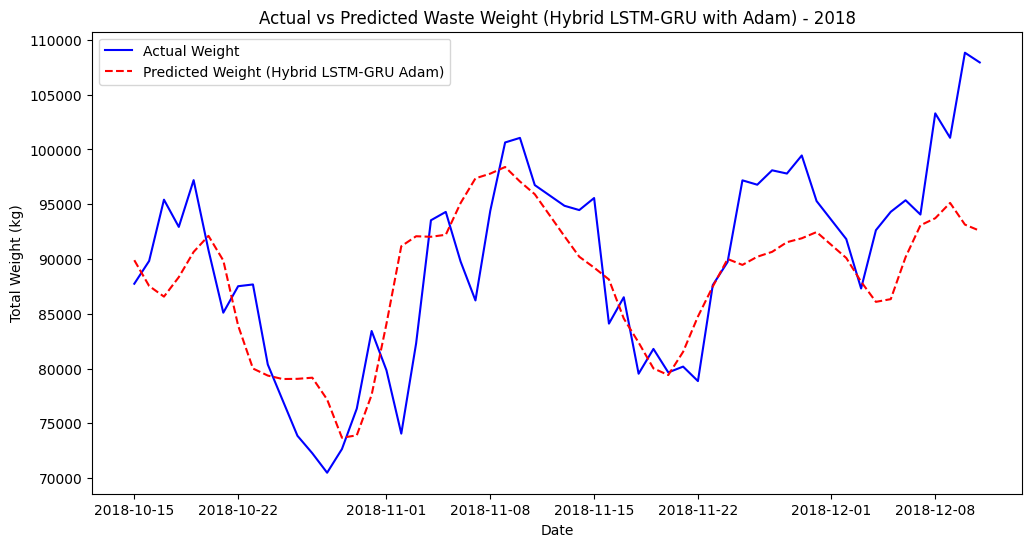

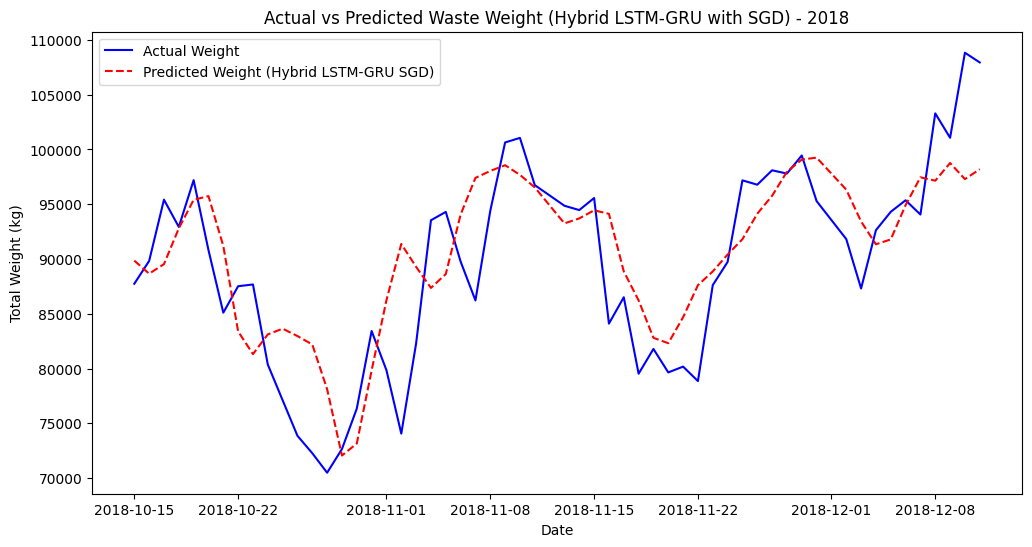

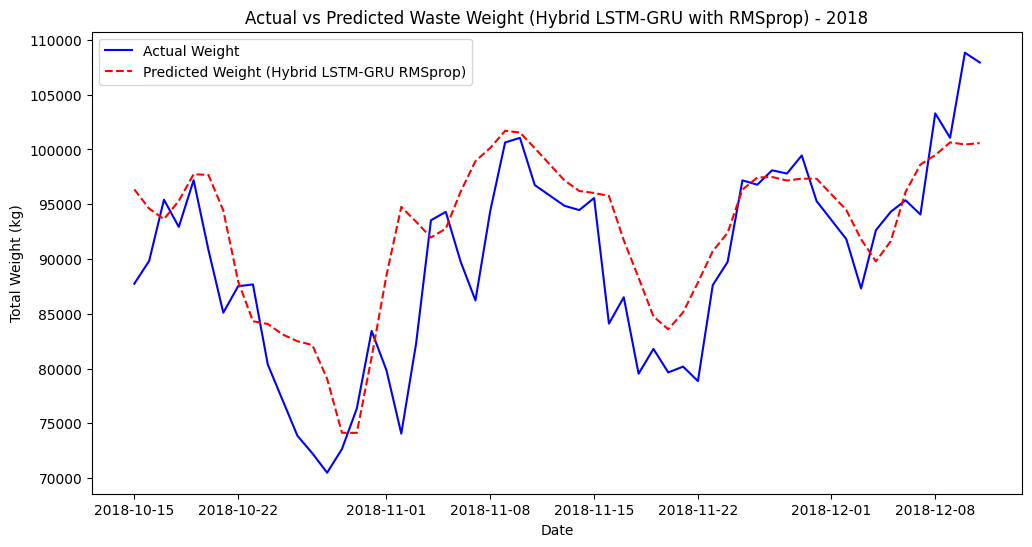

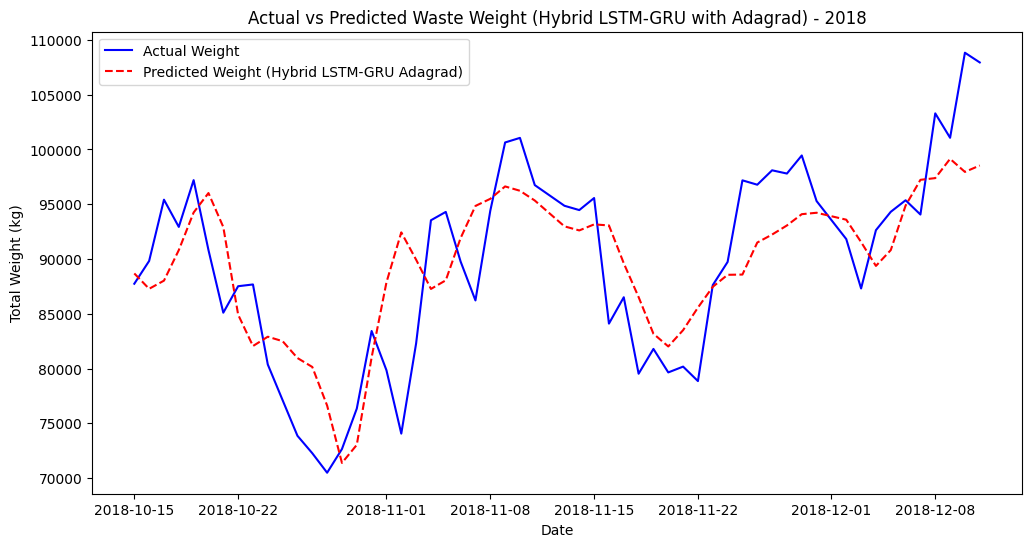

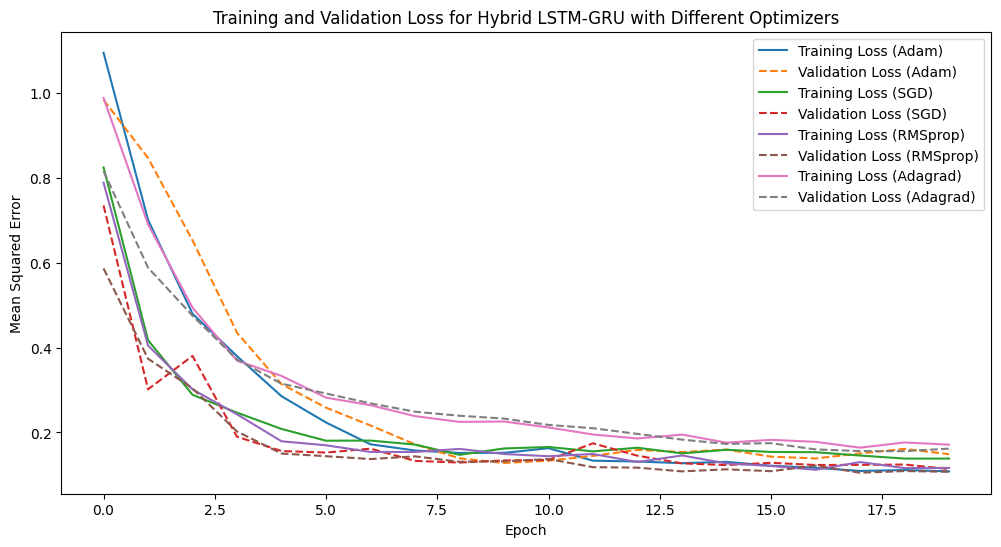

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adagrad

# Read data
df = pd.read_csv('dataset\moratuwa_2014-2018.csv')

# Preprocessing
df['ticket_date'] = pd.to_datetime(df['ticket_date'])
df = df.sort_values('ticket_date')

# Define waste types
waste_types = ['MSW', 'Sorted Organic Waste', 'Slaghter House Waste', 'Bulky Waste', 
               'Industrial Waste', 'Soil With Waste', 'Sanitary Waste', 'C&D Waste', 
               'Indutrial Sludge Waste', 'Soil', 'Saw Dust', 'Polythyne & Regiform', 
               'Mesuring', 'Wood Debris', 'Special Waste', 'Wood Trank']

# Aggregate by date, keeping waste_type
daily_data = df.groupby(['ticket_date', 'waste_type'])['net_weight_kg'].sum().unstack(fill_value=0).reset_index()
daily_data = daily_data.set_index('ticket_date')

# Add time-based features
daily_data['day_of_week'] = daily_data.index.dayofweek
daily_data['month'] = daily_data.index.month
daily_data['day_of_year'] = daily_data.index.dayofyear

# Total net_weight_kg
daily_data['total_weight'] = daily_data[waste_types].sum(axis=1)

# Outlier treatment using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# Cap outliers
lower_iqr, upper_iqr = detect_outliers_iqr(daily_data, 'total_weight')
daily_data_cleaned = daily_data.copy()
daily_data_cleaned['total_weight'] = daily_data_cleaned['total_weight'].clip(lower=lower_iqr, upper=upper_iqr)

# Define sequence length
seq_length = 30

# Function to process data for a specific year
def process_year_data(year):
    # Filter data for the specified year
    daily_data_year = daily_data_cleaned[daily_data_cleaned.index.year == year].copy()
    
    # Enhance data with subtle variability (1% noise)
    np.random.seed(42)  # For reproducibility
    daily_data_year['total_weight_enhanced'] = daily_data_year['total_weight'] * (1 + np.random.normal(0, 0.01, daily_data_year.shape[0]))
    
    # Add lagged feature and moving average
    daily_data_year['lag_1'] = daily_data_year['total_weight_enhanced'].shift(1)
    daily_data_year['ma_7'] = daily_data_year['total_weight_enhanced'].rolling(window=7).mean()
    daily_data_year = daily_data_year.dropna()

    # Prepare features
    features = waste_types + ['day_of_week', 'month', 'day_of_year', 'total_weight_enhanced', 'lag_1', 'ma_7']
    data_year = daily_data_year[features].values
    scaler = StandardScaler()
    data_scaled_year = scaler.fit_transform(data_year)

    # Create sequences
    def create_sequences(data, seq_length):
        X, y = [], []
        for i in range(len(data) - seq_length):
            X.append(data[i:i + seq_length, :-1])  # All features except total_weight_enhanced
            y.append(data[i + seq_length, -1])     # Predict total_weight_enhanced
        return np.array(X), np.array(y)

    X_year, y_year = create_sequences(data_scaled_year, seq_length)

    # Train-test split
    train_size = int(0.8 * len(X_year))
    X_train_year, X_test_year = X_year[:train_size], X_year[train_size:]
    y_train_year, y_test_year = y_year[:train_size], y_year[train_size:]
    test_dates_year = daily_data_year.index[seq_length + train_size:seq_length + len(X_year)]

    return X_train_year, X_test_year, y_train_year, y_test_year, test_dates_year, scaler, data_scaled_year.shape[1]

# Set the year to analyze
year_to_analyze = 2018

# Process data for the selected year
X_train_year, X_test_year, y_train_year, y_test_year, test_dates_year, scaler, n_features = process_year_data(year_to_analyze)

# Define optimizer configurations
optimizers = {
    'Adam': {'class': Adam, 'kwargs': {'learning_rate': 0.001}},
    'SGD': {'class': SGD, 'kwargs': {'learning_rate': 0.01, 'momentum': 0.9}},
    'RMSprop': {'class': RMSprop, 'kwargs': {'learning_rate': 0.001}},
    'Adagrad': {'class': Adagrad, 'kwargs': {'learning_rate': 0.01}}
}

# Function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    y_true = np.where(y_true == 0, 1e-10, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Function to create Hybrid LSTM-GRU model
def create_hybrid_model(optimizer):
    model = Sequential([
        LSTM(50, activation='tanh', input_shape=(seq_length, X_train_year.shape[2]), return_sequences=True),
        Dropout(0.2),
        GRU(50, activation='tanh', return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=optimizer, loss='mse')
    return model

# Train and evaluate Hybrid LSTM-GRU models with different optimizers
results = {}
for opt_name, opt_config in optimizers.items():
    print(f"\nTraining Hybrid LSTM-GRU with {opt_name} optimizer...")
    # Create fresh optimizer instance
    optimizer = opt_config['class'](**opt_config['kwargs'])
    model = create_hybrid_model(optimizer)
    history = model.fit(X_train_year, y_train_year, epochs=20, batch_size=32, validation_split=0.1, verbose=1)
    
    # Predict
    y_pred = model.predict(X_test_year)
    
    # Inverse transform
    dummy_pred = np.zeros((len(y_pred), n_features))
    dummy_pred[:, -1] = y_pred.flatten()
    y_pred_inv = scaler.inverse_transform(dummy_pred)[:, -1]
    
    dummy_test = np.zeros((len(y_test_year), n_features))
    dummy_test[:, -1] = y_test_year
    y_test_inv = scaler.inverse_transform(dummy_test)[:, -1]
    
    # Evaluate
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)
    r2 = r2_score(y_test_inv, y_pred_inv)
    print(f"Hybrid LSTM-GRU ({opt_name}) - MAE: {mae:.2f} kg, RMSE: {rmse:.2f} kg, MAPE: {mape:.2f}%, R²: {r2:.4f}")
    
    results[opt_name] = {
        'history': history.history,
        'y_pred_inv': y_pred_inv,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'r2': r2
    }

# Visualizations
# 1. Actual vs Predicted for each optimizer
for opt_name in optimizers.keys():
    plt.figure(figsize=(12, 6))
    plt.plot(test_dates_year, y_test_inv, label='Actual Weight', color='blue')
    plt.plot(test_dates_year, results[opt_name]['y_pred_inv'], 
             label=f'Predicted Weight (Hybrid LSTM-GRU {opt_name})', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Total Weight (kg)')
    plt.title(f'Actual vs Predicted Waste Weight (Hybrid LSTM-GRU with {opt_name}) - {year_to_analyze}')
    plt.legend()
    plt.savefig(f'hybrid_forecast_2018_{opt_name.lower()}.png')

# 2. Training and Validation Loss Comparison
plt.figure(figsize=(12, 6))
for opt_name in optimizers.keys():
    plt.plot(results[opt_name]['history']['loss'], 
             label=f'Training Loss ({opt_name})')
    plt.plot(results[opt_name]['history']['val_loss'], 
             label=f'Validation Loss ({opt_name})', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training and Validation Loss for Hybrid LSTM-GRU with Different Optimizers')
plt.legend()
plt.savefig('hybrid_lstm_gru_loss_comparison_2018.png')

<p style="font-family: Calibri, serif; text-align: left;
          font-size: 28px; letter-spacing: .85px; color: #ffffff;">Transfer learning for time series forecasting</p>

Pre-training Hybrid LSTM-GRU on 2014-2017 data...
Epoch 1/20
29/29 [==============================] - 6s 50ms/step - loss: 0.3534 - val_loss: 0.1412
Epoch 2/20
29/29 [==============================] - 1s 19ms/step - loss: 0.1343 - val_loss: 0.0965
Epoch 3/20
29/29 [==============================] - 1s 27ms/step - loss: 0.0949 - val_loss: 0.0806
Epoch 4/20
29/29 [==============================] - 1s 26ms/step - loss: 0.0810 - val_loss: 0.0745
Epoch 5/20
29/29 [==============================] - 1s 21ms/step - loss: 0.0762 - val_loss: 0.0740
Epoch 6/20
29/29 [==============================] - 1s 22ms/step - loss: 0.0748 - val_loss: 0.0756
Epoch 7/20
29/29 [==============================] - 1s 22ms/step - loss: 0.0726 - val_loss: 0.0703
Epoch 8/20
29/29 [==============================] - 1s 27ms/step - loss: 0.0686 - val_loss: 0.0708
Epoch 9/20
29/29 [==============================] - 1s 26ms/step - loss: 0.0596 - val_loss: 0.0746
Epoch 10/20
29/29 [==============================] - 1s 31m

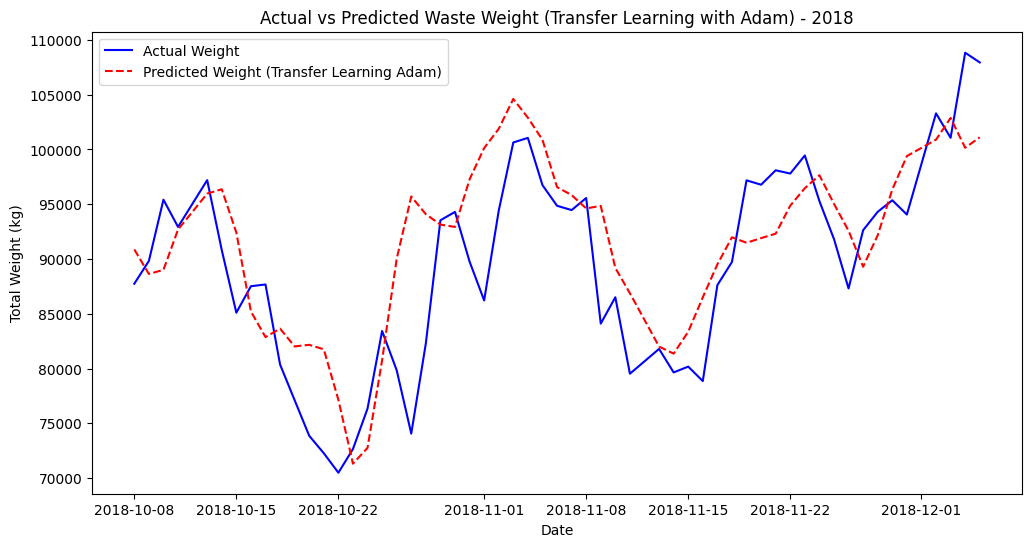

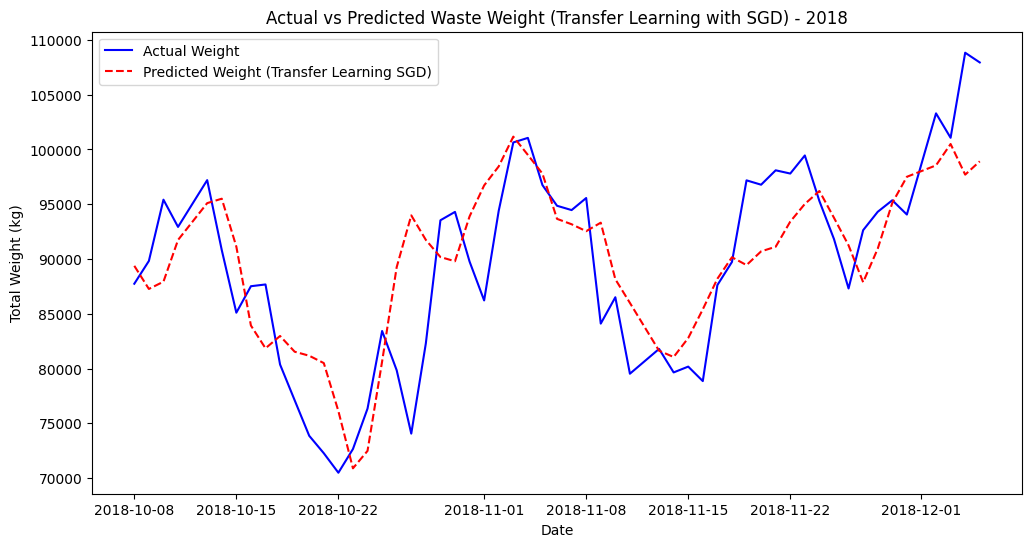

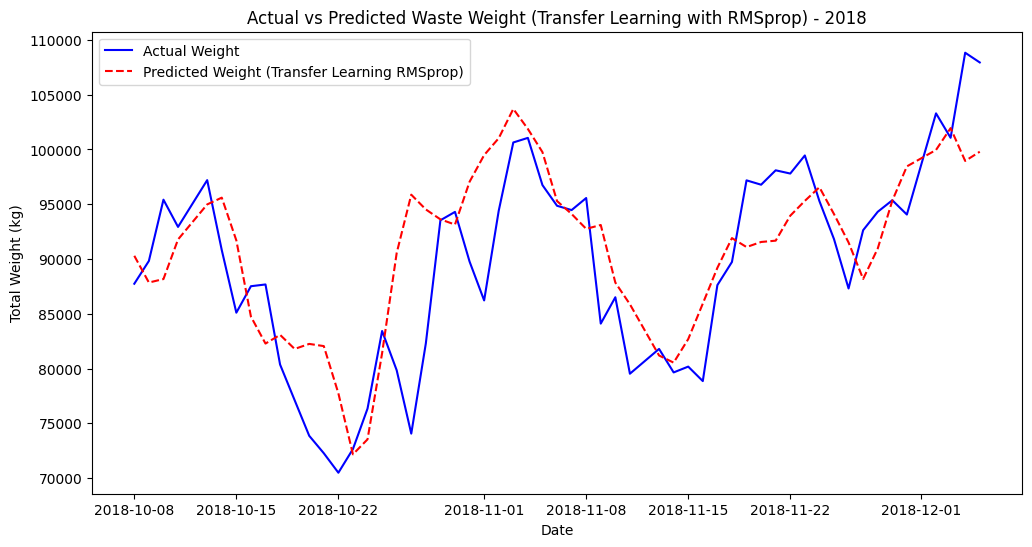

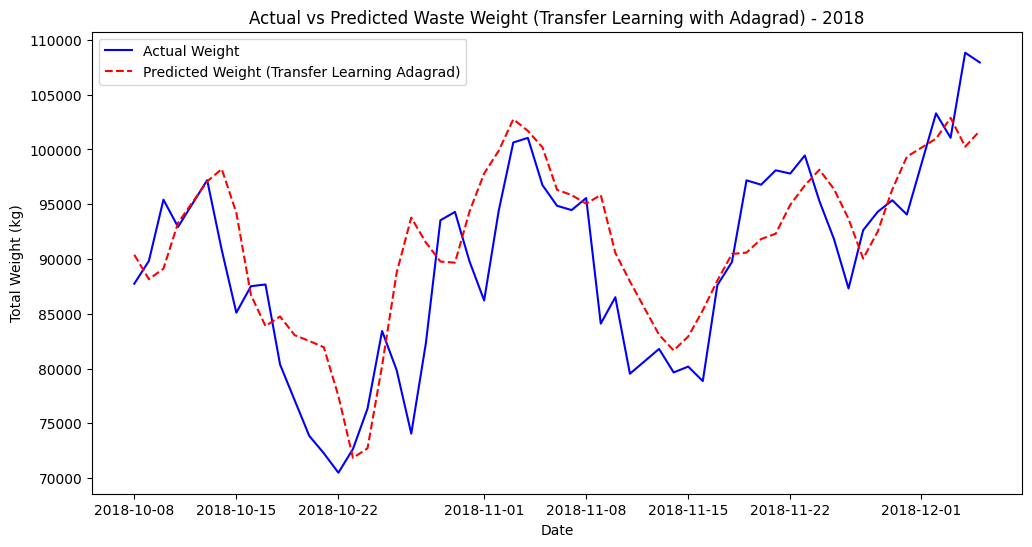

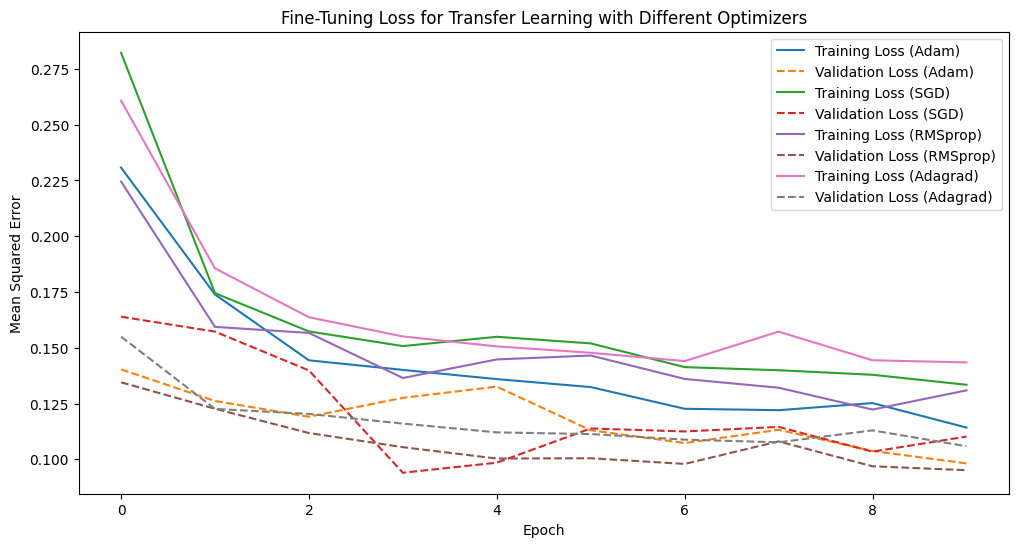

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adagrad

# Read data
df = pd.read_csv('dataset\moratuwa_2014-2018.csv')

# Preprocessing
df['ticket_date'] = pd.to_datetime(df['ticket_date'])
df = df.sort_values('ticket_date')

# Define waste types
waste_types = ['MSW', 'Sorted Organic Waste', 'Slaghter House Waste', 'Bulky Waste', 
               'Industrial Waste', 'Soil With Waste', 'Sanitary Waste', 'C&D Waste', 
               'Indutrial Sludge Waste', 'Soil', 'Saw Dust', 'Polythyne & Regiform', 
               'Mesuring', 'Wood Debris', 'Special Waste', 'Wood Trank']

# Aggregate by date, keeping waste_type
daily_data = df.groupby(['ticket_date', 'waste_type'])['net_weight_kg'].sum().unstack(fill_value=0).reset_index()
daily_data = daily_data.set_index('ticket_date')

# Add time-based features
daily_data['day_of_week'] = daily_data.index.dayofweek
daily_data['month'] = daily_data.index.month
daily_data['day_of_year'] = daily_data.index.dayofyear

# Total net_weight_kg
daily_data['total_weight'] = daily_data[waste_types].sum(axis=1)

# Outlier treatment using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# Cap outliers
lower_iqr, upper_iqr = detect_outliers_iqr(daily_data, 'total_weight')
daily_data_cleaned = daily_data.copy()
daily_data_cleaned['total_weight'] = daily_data_cleaned['total_weight'].clip(lower=lower_iqr, upper=upper_iqr)

# Function to process data for a specific year
def process_year_data(daily_data_cleaned, years, seq_length=30):
    # Filter data for the specified years
    daily_data_year = daily_data_cleaned[daily_data_cleaned.index.year.isin(years)].copy()
    
    # Enhance data with subtle variability (1% noise)
    np.random.seed(42)  # For reproducibility
    daily_data_year['total_weight_enhanced'] = daily_data_year['total_weight'] * (1 + np.random.normal(0, 0.01, daily_data_year.shape[0]))
    
    # Add lagged feature and moving average
    daily_data_year['lag_1'] = daily_data_year['total_weight_enhanced'].shift(1)
    daily_data_year['ma_7'] = daily_data_year['total_weight_enhanced'].rolling(window=7).mean()
    daily_data_year = daily_data_year.dropna()

    # Prepare features
    features = waste_types + ['day_of_week', 'month', 'day_of_year', 'total_weight_enhanced', 'lag_1', 'ma_7']
    data_year = daily_data_year[features].values
    scaler = StandardScaler()
    data_scaled_year = scaler.fit_transform(data_year)

    # Create sequences
    def create_sequences(data, seq_length):
        X, y = [], []
        for i in range(len(data) - seq_length):
            X.append(data[i:i + seq_length, :-1])  # All features except total_weight_enhanced
            y.append(data[i + seq_length, -1])  # Predict total_weight_enhanced
        return np.array(X), np.array(y)

    X_year, y_year = create_sequences(data_scaled_year, seq_length)
    return X_year, y_year, scaler, data_scaled_year.shape[1]

# Process data for pre-training (2014-2017)
X_pretrain, y_pretrain, _, _ = process_year_data(daily_data_cleaned, years=[2014, 2015, 2016, 2017])

# Process data for fine-tuning (2018)
X_2018, y_2018, scaler_2018, n_features = process_year_data(daily_data_cleaned, years=[2018])
train_size = int(0.8 * len(X_2018))
X_train_2018, X_test_2018 = X_2018[:train_size], X_2018[train_size:]
y_train_2018, y_test_2018 = y_2018[:train_size], y_2018[train_size:]
test_dates_2018 = daily_data_cleaned[daily_data_cleaned.index.year == 2018].index[train_size + 30:len(X_2018) + 30]

# Define optimizer configurations
optimizers = {
    'Adam': {'class': Adam, 'kwargs': {'learning_rate': 0.001}},
    'SGD': {'class': SGD, 'kwargs': {'learning_rate': 0.01, 'momentum': 0.9}},
    'RMSprop': {'class': RMSprop, 'kwargs': {'learning_rate': 0.001}},
    'Adagrad': {'class': Adagrad, 'kwargs': {'learning_rate': 0.01}}
}

# Function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    y_true = np.where(y_true == 0, 1e-10, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Function to create Hybrid LSTM-GRU model
def create_hybrid_model():
    model = Sequential([
        LSTM(50, activation='tanh', input_shape=(30, n_features-1), return_sequences=True),
        Dropout(0.2),
        GRU(50, activation='tanh', return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    return model

# Pre-train the model on 2014-2017 data
print("Pre-training Hybrid LSTM-GRU on 2014-2017 data...")
pretrain_model = create_hybrid_model()
pretrain_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
pretrain_model.fit(X_pretrain, y_pretrain, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

# Fine-tune and evaluate with different optimizers
results = {}
for opt_name, opt_config in optimizers.items():
    print(f"\nFine-tuning Hybrid LSTM-GRU with {opt_name} optimizer...")
    # Create a new model with pre-trained weights
    model = create_hybrid_model()
    model.set_weights(pretrain_model.get_weights())  # Transfer pre-trained weights
    optimizer = opt_config['class'](**opt_config['kwargs'])
    model.compile(optimizer=optimizer, loss='mse')
    
    # Fine-tune on 2018 data
    history = model.fit(X_train_2018, y_train_2018, epochs=10, batch_size=32, validation_split=0.1, verbose=1)
    
    # Predict
    y_pred = model.predict(X_test_2018)
    
    # Inverse transform
    dummy_pred = np.zeros((len(y_pred), n_features))
    dummy_pred[:, -1] = y_pred.flatten()
    y_pred_inv = scaler_2018.inverse_transform(dummy_pred)[:, -1]
    
    dummy_test = np.zeros((len(y_test_2018), n_features))
    dummy_test[:, -1] = y_test_2018
    y_test_inv = scaler_2018.inverse_transform(dummy_test)[:, -1]
    
    # Evaluate
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)
    r2 = r2_score(y_test_inv, y_pred_inv)
    print(f"Hybrid LSTM-GRU (Transfer Learning, {opt_name}) - MAE: {mae:.2f} kg, RMSE: {rmse:.2f} kg, MAPE: {mape:.2f}%, R²: {r2:.4f}")
    
    results[opt_name] = {
        'history': history.history,
        'y_pred_inv': y_pred_inv,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'r2': r2
    }

# Visualizations
# 1. Actual vs Predicted for each optimizer
for opt_name in optimizers.keys():
    plt.figure(figsize=(12, 6))
    plt.plot(test_dates_2018, y_test_inv, label='Actual Weight', color='blue')
    plt.plot(test_dates_2018, results[opt_name]['y_pred_inv'], 
             label=f'Predicted Weight (Transfer Learning {opt_name})', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Total Weight (kg)')
    plt.title(f'Actual vs Predicted Waste Weight (Transfer Learning with {opt_name}) - 2018')
    plt.legend()
    plt.savefig(f'transfer_learning_forecast_2018_{opt_name.lower()}.png')

# 2. Training and Validation Loss Comparison
plt.figure(figsize=(12, 6))
for opt_name in optimizers.keys():
    plt.plot(results[opt_name]['history']['loss'], 
             label=f'Training Loss ({opt_name})')
    plt.plot(results[opt_name]['history']['val_loss'], 
             label=f'Validation Loss ({opt_name})', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Fine-Tuning Loss for Transfer Learning with Different Optimizers')
plt.legend()
plt.savefig('transfer_learning_loss_comparison_2018.png')